# Import Model

In [70]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.act1  = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.shortcut = None
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        self.act2 = nn.SiLU()

    def forward(self, x):
        identity = x
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.act2(self.bn2(self.conv2(out)))
        if self.shortcut is not None:
            identity = self.shortcut(x)
        return out + identity



class DeepTileEncoder(nn.Module):
    """加深的 Tile 分支：全局信息，多尺度池化 + 三层 MLP"""
    def __init__(self, out_dim, in_channels=3, negative_slope=0.01):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(2)  # 78→39
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64),
            nn.MaxPool2d(2)  # 39→19
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128),
            nn.MaxPool2d(2)  # 19→9
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256),
            ResidualBlock(256, 256)
        )  # 保持 9×9

        # 多尺度池化
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # [B,256,1,1]
        self.mid_pool    = nn.AdaptiveAvgPool2d((3, 3))  # [B,256,3,3]

        total_dim = 256*1*1 + 256*3*3
        # 三层 MLP：total_dim → 2*out_dim → out_dim → out_dim
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.1),
            nn.Linear(total_dim, out_dim*4),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim*4, out_dim*2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim*2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # x: [B,256,9,9]
        g = self.global_pool(x).contiguous().reshape(x.size(0), -1)  # [B,256]
        m = self.mid_pool(x).contiguous().reshape(x.size(0), -1)     # [B,256*3*3]

        return self.fc(torch.cat([g, m], dim=1))

class TileEmbeddingEncoder(nn.Module):
    def __init__(self, in_dim=1536, out_dim=128, negative_slope=0.01):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim * 2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        # x: [B, 1536]
        return self.net(x)
class SubtileEmbeddingEncoder(nn.Module):
    def __init__(self, in_dim=1536, out_dim=128, negative_slope=0.01):
        super().__init__()
        self.proj = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim),
            nn.LeakyReLU(negative_slope),
        )

        self.fc = nn.Sequential(
            nn.Linear(out_dim, out_dim * 2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim * 2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        # x: [B, 9, 1536]
        x = self.proj(x)        # [B, 9, out_dim]
        x = x.mean(dim=1)      # [B, out_dim]
        return self.fc(x)
class CenterEmbeddingEncoder(nn.Module):
    def __init__(self, in_dim=1536, out_dim=128, negative_slope=0.01):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, out_dim * 2),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(out_dim * 2, out_dim),
            nn.LeakyReLU(negative_slope),
        )

    def forward(self, x):
        # x: [B, 1536]
        return self.net(x)

class EmbeddingMLP_MultiTask(nn.Module):
    def __init__(
        self,
        tile_dim=128,
        subtile_dim=128,
        embed_dim=1536,
        output_dim=35,
        negative_slope=0.01
    ):
        super().__init__()

        self.encoder_tile   = TileEmbeddingEncoder(embed_dim, tile_dim, negative_slope)
        self.encoder_sub    = SubtileEmbeddingEncoder(embed_dim, subtile_dim, negative_slope)
        self.encoder_center = CenterEmbeddingEncoder(embed_dim, subtile_dim, negative_slope)

        self.decoder = nn.Sequential(
            nn.Linear(subtile_dim * 2 + tile_dim, 256),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(0.1),
            nn.Linear(64, output_dim),
        )

    def forward(self, tile, subtiles):
        """
        tile_emb:     [B, 1536]
        subtiles_emb: [B, 9, 1536]
        """
        center_emb = subtiles[:, 4]  # center subtile

        f_tile   = self.encoder_tile(tile)
        f_sub    = self.encoder_sub(subtiles)
        f_center = self.encoder_center(center_emb)

        fused = torch.cat([ f_sub, f_center, f_tile], dim=1)
        return self.decoder(fused)



model = EmbeddingMLP_MultiTask(
    tile_dim=128,
    subtile_dim=128,
    embed_dim=1536,
    output_dim=35
)


# —— 5) 确保只有 decoder 可训练 ——  
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable / total params = {trainable:,} / {total:,}")


Trainable / total params = 1,266,595 / 1,266,595


## Load Model

# Import training data

## Same in multiple .pt

In [60]:
import os
import torch
import random
import inspect
import os
os.chdir("/Users/deweywang/Desktop/GitHub/HEVisum/")
from scripts.import_data import load_all_tile_data

# 用法範例
folder = "dataset/try_224/train_data/"

grouped_data = load_all_tile_data( 
        folder_path=folder,
        model=model,
        fraction=1,
        shuffle=False
    )

    # grouped_data 現在只會有 model.forward() 需要的 key，
    # 像 ['tile','subtiles','neighbors','norm_coord','node_feat','adj_list','edge_feat','label','source_idx']
print("Loaded keys:", grouped_data.keys())
print("Samples:", len(next(iter(grouped_data.values()))))


/Users/deweywang/Desktop/GitHub/HEVisum/scripts/import_data.py:251: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(fpath, map_location='cpu')


Loaded keys: dict_keys(['slide_idx', 'label', 'tile', 'subtiles', 'source_idx', 'position'])
Samples: 8348


In [52]:
import os
import torch
import csv
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
from scripts.operate_model import train_one_epoch, evaluate, predict, plot_losses, plot_per_cell_metrics,spear_EarlyStopping
import torch.nn as nn

# ---------------------------
# Your save_folder path for the plots and model
# ---------------------------
save_folder = "output_folder/try_embed/"  # 修改為你想要的資料夾名稱
if not os.path.exists(save_folder):   
    os.makedirs(save_folder)


In [64]:
# --------------------------------------------
# 2) 從 grouped_data 取出 slide_idx，轉成 numpy
# --------------------------------------------
import numpy as np
positions = np.array(grouped_data['position'])  # shape (N,2)

x = positions[:, 0]
y = positions[:, 1]

quad_groups = np.zeros(len(positions), dtype=int)

# quadrant encoding
# 0: 左下
# 1: 右下
# 2: 左上
# 3: 右上

quad_groups[(x >= 0) & (y < 0)] = 1
quad_groups[(x < 0) & (y >= 0)] = 2
quad_groups[(x >= 0) & (y >= 0)] = 3
slide_idx = np.array(grouped_data['slide_idx'])
unique_slides = np.unique(slide_idx)
unique_slides


array(['S_1', 'S_2', 'S_3', 'S_4', 'S_5', 'S_6'], dtype='<U3')

In [54]:
from torch.utils.data import Dataset

class EmbeddingDataset(Dataset):
    def __init__(self, grouped_data):
        self.tiles     = grouped_data["tile"]      # [N, 1536]
        self.subtiles  = grouped_data["subtiles"]   # [N, 9, 1536]
        self.labels    = grouped_data["label"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.tiles[idx],        # torch.Tensor [1536]
            self.subtiles[idx],     # torch.Tensor [9,1536]
            self.labels[idx]        # torch.Tensor [35]
        )

In [61]:
# --------------------------------------------
# 2) 從 grouped_data 取出 slide_idx，轉成 numpy
# --------------------------------------------
import numpy as np
slide_idx = np.array(grouped_data['slide_idx'])   # shape (N,)

# --------------------------------------------
# 3) 建立 LOGO（或改成 GroupKFold）
# --------------------------------------------
from sklearn.model_selection import LeaveOneGroupOut
logo = LeaveOneGroupOut()

# X 可以給虛擬矩陣，因為分組只靠 groups
X_dummy = np.zeros(len(slide_idx))
X_dummy

array([0., 0., 0., ..., 0., 0., 0.])

EarlyStopping counter: 5/5
[Epoch 9]  lr=7.94e-04, train_loss=39.1218, val_loss=52.2511
train spearman: 0.7955 | Val spearman: 0.6927 | best: 0.7013


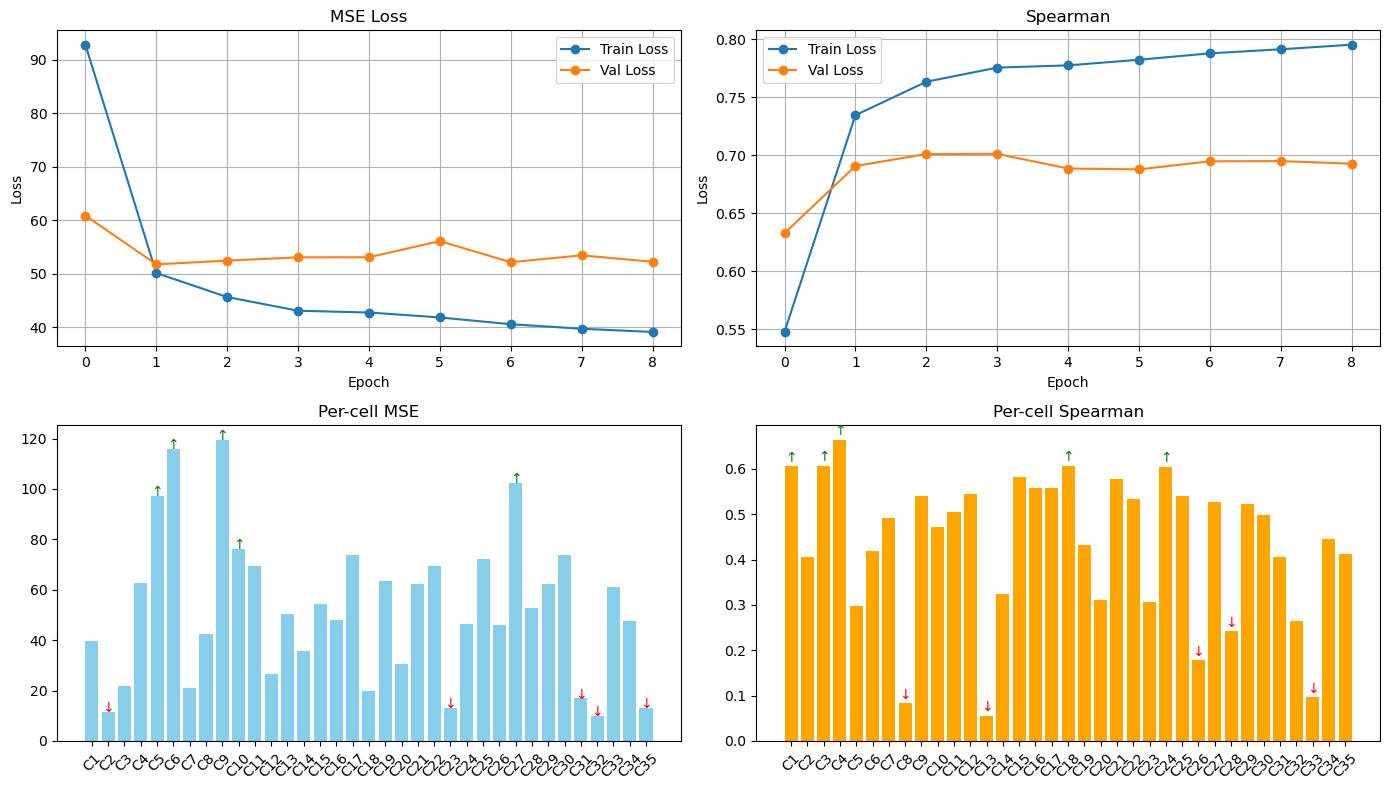

<Figure size 640x480 with 0 Axes>

save plots in output_folder/try_embed/fold3/loss_curve.png
⛔ early stop
📈 Fold 3 best ρ = 0.7013

=========== CV summary ===========
fold 0: best ρ = 0.7113
fold 1: best ρ = 0.7362
fold 2: best ρ = 0.7805
fold 3: best ρ = 0.7013
overall best (mean) ρ = 0.7323 ± 0.0306


In [72]:
from torch.utils.data import DataLoader
from scripts.import_data import importDataset
from scripts.aug         import augment_grouped_data, identity, subset_grouped_data
import math
from torch.optim.lr_scheduler import LambdaLR
# ---------------- 基本參數 ----------------
start_fold = 0   # 从第几个 fold 开始训练（0-based），小于此值的 fold 会跳过

BATCH_SIZE   = 32
num_epochs   = 150
repeats      = 2
# ---------------- 參數設定 ----------------
save_root    = save_folder          # 最外層
os.makedirs(save_root, exist_ok=True)

# Seed once at the very top for reproducibility
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=4)

device   = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("✅ device:", device)

overall_best = []
# 在你的脚本文件头部



# ➋ LOGO / GroupKFold 切分索引，對 Dataset 建 Subset
for fold_id, (tr_idx, va_idx) in enumerate(
        gkf.split(X=np.zeros(len(quad_groups)), y=None, groups=quad_groups)):
    
        # 如果当前 fold < start_fold，就跳过
    if fold_id < start_fold:
        print(f"⏭️ Skipping fold {fold_id}")
        continue
    
    print("Starting fold", fold_id)
    print("Starting subseting...")
    # ⭐ 選一張 slide 加進 validation
    # slide_for_val = unique_slides[fold_id % len(unique_slides)]

    # slide_val_idx = np.where(slide_idx == slide_for_val)[0]

    # # ⭐ 合併 validation index
    # va_idx = np.unique(np.concatenate([va_idx, slide_val_idx]))

    # ⭐ 重新定義 training index
    # tr_idx = np.setdiff1d(np.arange(len(slide_idx)), va_idx)
    print("Val slides:", np.unique(slide_idx[va_idx]))
    print("Val quadrants:", np.unique(quad_groups[va_idx]))

    train_base = subset_grouped_data(grouped_data, tr_idx)
    print("Starting augmenting...")
    print("Original train samples:", len(train_base['label']))
    # 1) 原始 dataset
    train_ds = EmbeddingDataset(train_base)


    # 3) validation raw
    val_ds   = EmbeddingDataset(subset_grouped_data(grouped_data, va_idx))

    print("Starting DataLoader...")
    # 4) DataLoader 不再動態增強
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=False)

    # 5) 一切其餘步驟同之前：定模型、optimizer、train_one_epoch、evaluate……

    print("Starting model...")
    # ----- 新建模型 / 優化器 -----
    net = EmbeddingMLP_MultiTask(
        tile_dim=128,
        subtile_dim=128,
        embed_dim=1536,
        output_dim=35
    )

    net = net.to(device)

    # 我们把原来 Adam 换成 AdamW，稍微加一点 weight decay
    peak_lr       = 1e-3
    min_lr        = 1e-6
    warmup_epochs = 0
    total_epochs  = 30

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, net.parameters()),
        lr=peak_lr, weight_decay=1e-3
    )

    # 定义 lr_lambda
    def lr_lambda(cur_epoch):
        if cur_epoch < warmup_epochs:
            # 线性 warm-up: 从 0 → 1
            return float(cur_epoch + 1) / warmup_epochs
        else:
            # 余弦退火：从 1 → min_lr/peak_lr
            progress = (cur_epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            # cos(0)=1 → cos(pi)=−1, remap to [min_ratio,1]
            min_ratio = min_lr / peak_lr
            return min_ratio + 0.5 * (1 - min_ratio) * (1 + math.cos(math.pi * progress))

    scheduler = LambdaLR(optimizer, lr_lambda)

    stopper = spear_EarlyStopping(patience=5)

    # ----- fold 專屬輸出路徑 -----
    fold_dir  = os.path.join(save_folder, f"fold{fold_id}")
    os.makedirs(fold_dir, exist_ok=True)
    best_model_path = os.path.join(fold_dir, "best_model.pt")
    loss_plot_path  = os.path.join(fold_dir, "loss_curve.png")
    csv_path        = os.path.join(fold_dir, "training_log.csv")

    # ----- CSV log -----
    log_f = open(csv_path, "w", newline="")
    csv_w = csv.writer(log_f)
    csv_w.writerow(["Epoch","TrainLoss","ValLoss","ValSpearman","LR"])

    # ----- 圖形 -----
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    display(fig)

    train_losses = []; val_losses = []
    train_rhos   = []; val_rhos   = []

    best_rho = -1.0
    print("Starting training...")
    for epoch in range(num_epochs):

        tloss, trho = train_one_epoch(
            net, train_loader, optimizer, device,
            current_epoch=epoch, initial_alpha=0, final_alpha=0, target_epoch=20 )

        vloss, vrho, mse_cell, rho_cell = evaluate(
            net, val_loader, device,
            current_epoch=epoch, initial_alpha=0, final_alpha=0, target_epoch=20 )

        clear_output(wait=True)  # 清除之前的輸出
        axes[0][0].clear()
        axes[0][1].clear()
        axes[1][0].clear()
        axes[1][1].clear()
        # --- save best ---
        if vrho > best_rho:
            best_rho = vrho
            torch.save(net.state_dict(), best_model_path)
            print(f"✅ Saved best model in {best_model_path}!")

        # --- scheduler / early stop ---
        scheduler.step()
        stopper(vrho)


    
        # --- logging ---
        lr = optimizer.param_groups[0]['lr']
        csv_w.writerow([epoch+1, tloss, vloss, vrho, lr])

        train_losses.append(tloss); val_losses.append(vloss)
        train_rhos.append(trho);   val_rhos.append(vrho)
        

        

        # 印出 Epoch 結果
        lr = optimizer.param_groups[0]['lr']
        print(f"[Epoch {epoch+1}]  lr={lr:.2e}, train_loss={tloss:.4f}, val_loss={vloss:.4f}")
        print(f"train spearman: {trho:.4f} | Val spearman: {vrho:.4f} | best: {best_rho:.4f}")
        # --- update plots ---
        plot_losses(train_losses, val_losses, axes[0][0], "MSE Loss")
        plot_losses(train_rhos,   val_rhos,   axes[0][1], "Spearman")
        cell_names = [f"C{i+1}" for i in range(35)]
        plot_per_cell_metrics(mse_cell, rho_cell, cell_names,
                              ax_mse=axes[1][0], ax_spearman=axes[1][1])
        plt.tight_layout(); display(fig); plt.pause(0.1)
        fig.savefig(loss_plot_path)
        print(f"save plots in {loss_plot_path}")
        if stopper.early_stop:
            print("⛔ early stop"); break

    log_f.close(); plt.close(fig)
    overall_best.append(best_rho) 
    print(f"📈 Fold {fold_id} best ρ = {best_rho:.4f}")

# ========= 整體結果 =========
overall_best = np.array(overall_best)
print("\n=========== CV summary ===========")
for i, r in enumerate(overall_best):
    print(f"fold {i}: best ρ = {r:.4f}")
print(f"overall best (mean) ρ = {overall_best.mean():.4f} ± {overall_best.std():.4f}")

# Predict

In [23]:
import torch
import inspect
from scripts.operate_model import get_model_inputs
from scripts.import_data import load_node_feature_data


# 用法示例
from scripts.import_data import importDataset
# 假设你的 model 已经定义好并实例化为 `model`
test_dataset = load_node_feature_data("dataset/try_224/test/test_dataset.pt", model)
test_dataset = importDataset(
        data_dict=test_dataset,
        model=model,
        image_keys=['tile','subtiles'],
        transform=lambda x: x,  # identity transform
        print_sig=True
    )



/Users/deweywang/Desktop/GitHub/HEVisum/scripts/import_data.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw = torch.load(pt_path, map_location="cpu")


⚠️ 從 '<class 'list'>' 推斷樣本數量: 2088
Model forward signature: (tile, subtiles)


In [24]:
from torch.utils.data import DataLoader
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [73]:
import glob
import torch
import numpy as np
import pandas as pd
import os
import h5py
from torch.utils.data import DataLoader

# 讀 test spot index
with h5py.File("./dataset/elucidata_ai_challenge_data.h5","r") as f:
    test_spots     = f["spots/Test"]
    test_spot_table= pd.DataFrame(np.array(test_spots['S_7']))

fold_ckpts = sorted(glob.glob(os.path.join(save_folder, "fold*", "best_model.pt")))
models = []
for ckpt in fold_ckpts:
    net = EmbeddingMLP_MultiTask(
        tile_dim=128,
        subtile_dim=128,
        embed_dim=1536,
        output_dim=35
    )
    net = net.to(device)
    net.load_state_dict(torch.load(ckpt, map_location="cpu"))
    net.to(device).eval()
    models.append(net)

all_fold_preds = []
for fold_id, net in enumerate(models):
    # 推論
    with torch.no_grad():
        preds = predict(net, test_loader, device)  # (N_test,35) numpy array

    # 1) 存每一折的原始預測
    df_fold = pd.DataFrame(preds, columns=[f"C{i+1}" for i in range(preds.shape[1])])
    df_fold.insert(0, "ID", test_spot_table.index)
    path_fold = os.path.join(save_folder, f"submission_fold{fold_id}.csv")
    df_fold.to_csv(path_fold, index=False)
    print(f"✅ Saved fold {fold_id} predictions to {path_fold}")

    all_fold_preds.append(preds)

# 2) 做 rank‐average ensemble
all_fold_preds = np.stack(all_fold_preds, axis=0)       # (K, N_test, 35)
ranks          = all_fold_preds.argsort(axis=2).argsort(axis=2).astype(float)
mean_rank      = ranks.mean(axis=0)                    # (N_test,35)

# 3) 存 final ensemble
df_ens = pd.DataFrame(mean_rank, columns=[f"C{i+1}" for i in range(mean_rank.shape[1])])
df_ens.insert(0, "ID", test_spot_table.index)
path_ens = os.path.join(save_folder, "submission_rank_ensemble.csv")
df_ens.to_csv(path_ens, index=False)
print(f"✅ Saved rank‐ensemble submission to {path_ens}")


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_45686/2863249120.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(ckpt, map_loc

✅ Saved fold 0 predictions to output_folder/try_embed/submission_fold0.csv
✅ Saved fold 1 predictions to output_folder/try_embed/submission_fold1.csv
✅ Saved fold 2 predictions to output_folder/try_embed/submission_fold2.csv
✅ Saved fold 3 predictions to output_folder/try_embed/submission_fold3.csv
✅ Saved rank‐ensemble submission to output_folder/try_embed/submission_rank_ensemble.csv
